In [1]:
# === Cell 1: Setup, Imports, and Data Loading ===

# --- Core Data Handling & System Libraries ---
import pandas as pd
import os
import joblib
import sqlite3
import warnings
import traceback

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn and Imblearn Imports ---
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN  # Using the advanced sampler

# --- Google Gemini Imports for Labeling ---
import google.generativeai as genai
from tqdm.notebook import tqdm
import time

# --- Notebook Setup ---
# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore')
# Configure pandas display options for wider tables
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

print("--- Starting Feature Extraction and Modeling Notebook ---")

# --- Define File Paths ---
# Input file from the previous pre-processing notebook
input_final_data_filename = "preprocess_final.csv"

# Output directory for all saved models and components
output_dir_models = "Saved_Models"

# --- Create Output Directory if it Doesn't Exist ---
if not os.path.exists(output_dir_models):
    os.makedirs(output_dir_models)
    print(f"Created output directory for models: {output_dir_models}")

# --- Load Preprocessed Data ---
print(f"\n--- Loading Final Preprocessed Data ---")
if os.path.exists(input_final_data_filename):
    df_processed = pd.read_csv(input_final_data_filename, encoding='utf-8-sig')
    # Ensure 'Lemmatized_Text' is treated as a string and fill any potential null values
    df_processed['Lemmatized_Text'] = df_processed['Lemmatized_Text'].fillna('').astype(str)
    print(f"Successfully loaded {input_final_data_filename}: {df_processed.shape[0]} rows.")
    display(df_processed.head())
else:
    print(f"[ERROR] File not found: {input_final_data_filename}. Please run the data pre-processing notebook first.")
    # Create an empty DataFrame to prevent errors in subsequent cells
    df_processed = pd.DataFrame()

--- Starting Feature Extraction and Modeling Notebook ---

--- Loading Final Preprocessed Data ---
Successfully loaded preprocess_final.csv: 7912 rows.


,Platform,Question_Log_URL,Date,Sentence_Text,Lemmatized_Text
0,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM","Yes, a Coursera certificate can be quite useful.",yes coursera certificate quite useful
1,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM",While it may not hold the same weight as a deg...,may hold weight degree demonstrate commitment ...
2,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM","Many employers recognize Coursera courses, esp...",many employer recognize coursera course especi...
3,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM","Additionally, completing these courses can hel...",additionally complete course help gain practic...
4,Coursera,https://www.quora.com/Is-a-Coursera-certificat...,"October 25, 2024 at 10:33:45 PM",If you're looking for more certification optio...,youre look certification option could compleme...


In [2]:
# === Cell 2: AI-Powered Labeling using Gemini API ===

import pandas as pd
import os
import time
import google.generativeai as genai
from tqdm import tqdm

print("--- Starting AI-Powered Labeling Process ---")

# --- 1. Configure Gemini API ---
# Ensure the df_processed DataFrame from Cell 1 is available and not empty.
if 'df_processed' in locals() and not df_processed.empty:
    try:
        # IMPORTANT: Replace "YOUR_GEMINI_API_KEY" with your actual key.
        # It's recommended to use environment variables or a key management service for this in a real application.
        genai.configure(api_key="YOUR_GEMINI_API_KEY")
        
        # Initialize the specific model you want to use.
        model = genai.GenerativeModel('gemini-1.5-flash-latest')
        print("\nGemini API configured successfully.")
    except Exception as e:
        print(f"[ERROR] Error configuring Gemini API: {e}")
        # Stop execution of this cell if API is not configured
        model = None
else:
    print("[ERROR] 'df_processed' DataFrame not found or empty. Halting labeling.")
    model = None

# --- 2. Helper Function for Robust API Calls ---
def get_gemini_response(prompt_text, retries=3, delay=5):
    """
    Sends a prompt to the Gemini API and handles potential errors with a retry mechanism.
    """
    for i in range(retries):
        try:
            response = model.generate_content(prompt_text)
            # Clean up the response to get only the label text.
            return response.text.strip()
        except Exception as e:
            print(f"  [WARN] API Error on attempt {i+1}/{retries}: {e}. Retrying in {delay} seconds...")
            time.sleep(delay)
    return "API_Error" # Return a specific error string if all retries fail.

# --- Perform Aspect and Sentiment Labeling ---
if model:
    # --- Define Output Filenames for progress saving ---
    aspect_output_filename = "gemini_aspect_labels.csv"
    sentiment_output_filename = "gemini_sentiment_labels.csv"

    # --- Task A: Aspect Labeling ---
    print("\n--- Starting Aspect Labeling ---")
    aspect_categories = ['Content', 'Structure', 'Assessment', 'Interaction', 'Instructor']
    
    # Load existing progress to avoid re-running completed work.
    if os.path.exists(aspect_output_filename):
        aspect_results_df = pd.read_csv(aspect_output_filename)
        aspect_results = aspect_results_df.to_dict('records')
        print(f"Loaded {len(aspect_results)} existing aspect labels from '{aspect_output_filename}'.")
    else:
        aspect_results = []

    # Loop through the dataframe, starting from where we left off.
    start_index_aspect = len(aspect_results)
    for index, row in tqdm(df_processed.iloc[start_index_aspect:].iterrows(), 
                           total=len(df_processed) - start_index_aspect,
                           desc="Labeling Aspects"):
        
        sentence = row['Lemmatized_Text']
        
        # Define the prompt for aspect classification.
        aspect_prompt = f"""You are an expert in analyzing educational reviews. 
        Classify the following review sentence into ONLY ONE of the following categories: {aspect_categories}. 
        The sentence may touch on multiple topics, but please choose the single MOST prominent aspect. 
        Review sentence: '{sentence}'. Your response must be only ONE of the category names from the list and nothing else."""
        
        predicted_label = get_gemini_response(aspect_prompt)
        aspect_results.append({'Lemmatized_Text': sentence, 'Aspect_Label': predicted_label})
        
        # Save progress every 20 reviews to minimize data loss on interruption.
        if (index + 1) % 20 == 0:
            pd.DataFrame(aspect_results).to_csv(aspect_output_filename, index=False, encoding='utf-8-sig')

    # Final save for aspect labels.
    pd.DataFrame(aspect_results).to_csv(aspect_output_filename, index=False, encoding='utf-8-sig')
    print("Aspect labeling completed and all progress saved.")

    # --- Task B: Sentiment Labeling ---
    print("\n--- Starting Sentiment Labeling ---")
    sentiment_categories = ['Positive', 'Negative', 'Neutral']
    
    # Load existing progress.
    if os.path.exists(sentiment_output_filename):
        sentiment_results_df = pd.read_csv(sentiment_output_filename)
        sentiment_results = sentiment_results_df.to_dict('records')
        print(f"Loaded {len(sentiment_results)} existing sentiment labels from '{sentiment_output_filename}'.")
    else:
        sentiment_results = []
        
    # Loop through the dataframe, starting from where we left off.
    start_index_sentiment = len(sentiment_results)
    for index, row in tqdm(df_processed.iloc[start_index_sentiment:].iterrows(), 
                           total=len(df_processed) - start_index_sentiment,
                           desc="Labeling Sentiments"):
                           
        sentence = row['Lemmatized_Text']
        
        # Define the prompt for sentiment classification.
        sentiment_prompt = f"""Analyze the sentiment of the following review sentence from a MOOC platform. 
        Classify the sentiment into ONLY ONE of these three labels: {sentiment_categories}. 
        Review sentence: '{sentence}'. Your response must be only ONE of the three sentiment labels and nothing else."""
        
        predicted_sentiment = get_gemini_response(sentiment_prompt)
        sentiment_results.append({'Lemmatized_Text': sentence, 'sentiment_label': predicted_sentiment})
        
        # Save progress every 20 reviews.
        if (index + 1) % 20 == 0:
            pd.DataFrame(sentiment_results).to_csv(sentiment_output_filename, index=False, encoding='utf-8-sig')
            
    # Final save for sentiment labels.
    pd.DataFrame(sentiment_results).to_csv(sentiment_output_filename, index=False, encoding='utf-8-sig')
    print("Sentiment labeling completed and all progress saved.")

else:
    print("\nAPI not configured. Skipping labeling process.")

--- Starting AI-Powered Labeling Process ---

Gemini API configured successfully.

--- Starting Aspect Labeling ---
Loaded 7912 existing aspect labels from 'gemini_aspect_labels.csv'.


Labeling Aspects: 0it [00:00, ?it/s]

Aspect labeling completed and all progress saved.

--- Starting Sentiment Labeling ---
Loaded 7912 existing sentiment labels from 'gemini_sentiment_labels.csv'.



Labeling Sentiments: 0it [00:00, ?it/s]

Sentiment labeling completed and all progress saved.


In [3]:
# === Cell 3: Data Integration, Filtering, and Final Verification ===

import pandas as pd
import os

print("--- Starting Data Integration and Filtering ---")

# --- Define Input Filenames ---
aspect_labels_file = "gemini_aspect_labels.csv"
sentiment_labels_file = "gemini_sentiment_labels.csv"

if ('df_processed' in locals() and not df_processed.empty and
    os.path.exists(aspect_labels_file) and os.path.exists(sentiment_labels_file)):

    # --- 1. Load and Synchronize Labels ---
    aspect_labels_df = pd.read_csv(aspect_labels_file)
    sentiment_labels_df = pd.read_csv(sentiment_labels_file)

    if len(aspect_labels_df) == len(df_processed) and len(sentiment_labels_df) == len(df_processed):
        df_processed['Aspect_Label'] = aspect_labels_df['Aspect_Label']
        df_processed['sentiment_label'] = sentiment_labels_df['sentiment_label']
        print("Successfully synchronized aspect and sentiment labels.")
    else:
        raise ValueError("CRITICAL ROW MISMATCH! Labeled rows do not match original DataFrame.")

    # --- 2. REFINEMENT: Filter out unwanted and single-member aspects ---
    print("\nFiltering data to remove unwanted and single-member categories...")
    rows_before_filter = len(df_processed)

    # Add 'Cost' and 'Accessibility' to the list of aspects to remove
    aspects_to_remove = ['Cost', 'Accessibility', 'API_Error'] # You can add more if needed
    sentiments_to_remove = ['Mixed', 'API_Error']

    print(f"Removing aspects: {aspects_to_remove}")
    print(f"Removing sentiments: {sentiments_to_remove}")

    # Create masks to keep only the desired rows.
    aspect_mask = ~df_processed['Aspect_Label'].isin(aspects_to_remove)
    sentiment_mask = ~df_processed['sentiment_label'].isin(sentiments_to_remove)

    # Apply the masks to the DataFrame.
    df_processed = df_processed[aspect_mask & sentiment_mask].copy()

    # Reset the index to be clean and sequential after filtering.
    df_processed.reset_index(drop=True, inplace=True)

    print(f"\nRows before filtering: {rows_before_filter}")
    print(f"Rows after filtering: {len(df_processed)}")

    # --- 3. Final Verification ---
    print("\n--- Final Labeled Data is Ready for Modeling ---")
    print("\nFinal Aspect distribution:")
    print(df_processed['Aspect_Label'].value_counts())

    print("\nFinal Sentiment distribution:")
    print(df_processed['sentiment_label'].value_counts())

else:
    print("[ERROR] Could not proceed. One or more required files or DataFrames are missing.")

--- Starting Data Integration and Filtering ---
Successfully synchronized aspect and sentiment labels.

Filtering data to remove unwanted and single-member categories...
Removing aspects: ['Cost', 'Accessibility', 'API_Error']
Removing sentiments: ['Mixed', 'API_Error']

Rows before filtering: 7912
Rows after filtering: 7910

--- Final Labeled Data is Ready for Modeling ---

Final Aspect distribution:
Aspect_Label
Content        5001
Instructor     1228
Structure       656
Interaction     541
Assessment      484
Name: count, dtype: int64

Final Sentiment distribution:
sentiment_label
Positive    4793
Neutral     2249
Negative     868
Name: count, dtype: int64


In [4]:
# === Cell 4: Initial Data Split (90% Development, 10% Hold-Out Validation) ===

import pandas as pd
from sklearn.model_selection import train_test_split

print("--- Starting Initial Data Split ---")

# Ensure the df_processed DataFrame from Cell 3 is available and not empty.
if 'df_processed' in locals() and not df_processed.empty:
    
    # --- Define Features (X) and Target (y) ---
    # The 'Lemmatized_Text' column will be our feature.
    # We will predict both Aspect and Sentiment, so we keep both labels for now.
    X = df_processed['Lemmatized_Text']
    y_aspect = df_processed['Aspect_Label']
    y_sentiment = df_processed['sentiment_label']

    # --- Perform the 90/10 Split ---
    # We create a development set for all training/tuning and a final validation set.
    # We will stratify based on the Aspect_Label to ensure both sets have a similar
    # distribution of aspect categories. This is important for training the aspect model.
    
    # We split the indices of the dataframe, which makes it easier to manage both X and y.
    dev_indices, val_indices = train_test_split(
        df_processed.index,
        test_size=0.10,       # Reserve 10% of the data for the final hold-out validation set.
        random_state=42,      # Ensures the split is reproducible.
        stratify=df_processed['Aspect_Label'] # Stratify by aspect to maintain distribution.
    )

    # --- Create the Development and Validation DataFrames ---
    # Use the indices to select the rows for each set.
    df_dev = df_processed.loc[dev_indices].copy()
    df_val = df_processed.loc[val_indices].copy()
    
    # Reset the index for both new dataframes for clean processing later.
    df_dev.reset_index(drop=True, inplace=True)
    df_val.reset_index(drop=True, inplace=True)
    
    # --- Verification ---
    print("\n--- Data Split Summary ---")
    print(f"Total original rows: {len(df_processed)}")
    print(f"Development set size (90%): {len(df_dev)} rows")
    print(f"Hold-Out Validation set size (10%): {len(df_val)} rows")

    print("\nAspect distribution in Development Set:")
    print(df_dev['Aspect_Label'].value_counts(normalize=True).round(3))
    
    print("\nAspect distribution in Validation Set:")
    print(df_val['Aspect_Label'].value_counts(normalize=True).round(3))
    
    print("\n[SUCCESS] Data successfully split into development and hold-out validation sets.")

else:
    print("[ERROR] 'df_processed' DataFrame not found or empty. Halting process.")

--- Starting Initial Data Split ---

--- Data Split Summary ---
Total original rows: 7910
Development set size (90%): 7119 rows
Hold-Out Validation set size (10%): 791 rows

Aspect distribution in Development Set:
Aspect_Label
Content        0.632
Instructor     0.155
Structure      0.083
Interaction    0.068
Assessment     0.061
Name: proportion, dtype: float64

Aspect distribution in Validation Set:
Aspect_Label
Content        0.632
Instructor     0.155
Structure      0.083
Interaction    0.068
Assessment     0.061
Name: proportion, dtype: float64

[SUCCESS] Data successfully split into development and hold-out validation sets.


In [5]:
# === Cell 5: Feature Extraction with TF-IDF ===

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Starting Feature Extraction (TF-IDF) ---")

# Ensure the development and validation DataFrames from Cell 4 are available.
if 'df_dev' in locals() and 'df_val' in locals():
    
    # --- 1. Initialize the TF-IDF Vectorizer ---
    # We can set parameters like max_df and min_df to ignore terms that are too common or too rare.
    tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english', ngram_range=(1, 2))

    # --- 2. Fit and Transform the Development Set ---
    # CRITICAL STEP: We fit the vectorizer ONLY on the development data.
    # This learns the vocabulary and IDF weights from the training portion only.
    print(f"\nFitting TF-IDF vectorizer on the {len(df_dev)} rows of the Development Set...")
    X_dev = tfidf_vectorizer.fit_transform(df_dev['Lemmatized_Text'])
    
    # The 'y' variables are the corresponding labels for the development set.
    y_aspect_dev = df_dev['Aspect_Label']
    y_sentiment_dev = df_dev['sentiment_label']
    
    # --- 3. Transform the Hold-Out Validation Set ---
    # We use the *same fitted vectorizer* to transform the validation data.
    # This ensures consistency and prevents data leakage.
    print(f"Transforming the {len(df_val)} rows of the Hold-Out Validation Set...")
    X_val = tfidf_vectorizer.transform(df_val['Lemmatized_Text'])
    
    # The 'y' variables for the validation set.
    y_aspect_val = df_val['Aspect_Label']
    y_sentiment_val = df_val['sentiment_label']
    
    # --- 4. Verification ---
    print("\n--- Feature Extraction Summary ---")
    print(f"Shape of Development Set (X_dev): {X_dev.shape}")
    print(f"Shape of Hold-Out Validation Set (X_val): {X_val.shape}")
    print("\n[SUCCESS] Text data has been successfully converted into numerical features.")

else:
    print("[ERROR] Development ('df_dev') or validation ('df_val') DataFrames not found. Halting process.")
    print("Please ensure Cell 4 has run successfully.")

--- Starting Feature Extraction (TF-IDF) ---

Fitting TF-IDF vectorizer on the 7119 rows of the Development Set...
Transforming the 791 rows of the Hold-Out Validation Set...

--- Feature Extraction Summary ---
Shape of Development Set (X_dev): (7119, 12374)
Shape of Hold-Out Validation Set (X_val): (791, 12374)

[SUCCESS] Text data has been successfully converted into numerical features.


--- Starting Aspect Extraction Model Training and Evaluation ---

Performing 5-Fold Stratified Cross-Validation with detailed metrics...

--- Fold 1 ---
Accuracy : 0.8013
Precision: 0.8262
Recall   : 0.6138
F1-Score : 0.6887

--- Fold 2 ---
Accuracy : 0.8083
Precision: 0.8266
Recall   : 0.6346
F1-Score : 0.7061

--- Fold 3 ---
Accuracy : 0.8062
Precision: 0.8576
Recall   : 0.6163
F1-Score : 0.6998

--- Fold 4 ---
Accuracy : 0.7921
Precision: 0.8219
Recall   : 0.6062
F1-Score : 0.6804

--- Fold 5 ---
Accuracy : 0.7906
Precision: 0.8248
Recall   : 0.5832
F1-Score : 0.6633


=== Cross-Validation Metrics Summary ===


,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.801264,0.826158,0.613753,0.688670
1,2,0.808287,0.826552,0.634631,0.706103
2,3,0.806180,0.857554,0.616344,0.699765
3,4,0.792135,0.821862,0.606194,0.680411
4,5,0.790583,0.824819,0.583241,0.663345



Average CV Accuracy: 0.7997 (+/- 0.0161)

Best fold is Fold 2 with F1-Score = 0.7061


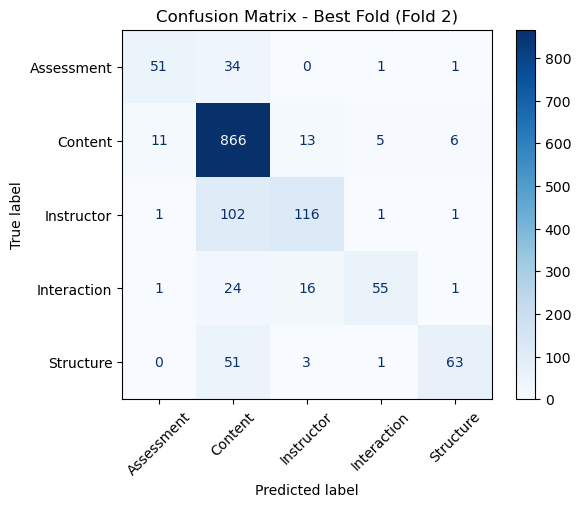


=== Classification Report for Best Fold ===
              precision    recall  f1-score   support

  Assessment       0.80      0.59      0.68        87
     Content       0.80      0.96      0.88       901
  Instructor       0.78      0.52      0.63       221
 Interaction       0.87      0.57      0.69        97
   Structure       0.88      0.53      0.66       118

    accuracy                           0.81      1424
   macro avg       0.83      0.63      0.71      1424
weighted avg       0.81      0.81      0.79      1424


Training final aspect extraction model on the full development set...
Aspect extraction model training complete.

Saved aspect extraction model to 'aspect_extraction_model.joblib'


In [6]:
# === Cell 6: Train and Evaluate the Aspect Extraction Model ===

import pandas as pd
import numpy as np
import joblib
import os
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("--- Starting Aspect Extraction Model Training and Evaluation ---")

if 'X_dev' in locals() and 'y_aspect_dev' in locals():

    aspect_model = SVC(kernel='linear', C=1, random_state=42)

    k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("\nPerforming 5-Fold Stratified Cross-Validation with detailed metrics...\n")
    fold_metrics = []
    fold_preds = []

    for fold_idx, (train_idx, test_idx) in enumerate(k_fold.split(X_dev, y_aspect_dev), 1):
        X_train, X_test = X_dev[train_idx], X_dev[test_idx]
        y_train, y_test = y_aspect_dev.iloc[train_idx], y_aspect_dev.iloc[test_idx]

        model = SVC(kernel='linear', C=1, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        fold_metrics.append({
            'Fold': fold_idx,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

        fold_preds.append({
            'Fold': fold_idx,
            'y_true': y_test,
            'y_pred': y_pred
        })

        print(f"--- Fold {fold_idx} ---")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-Score : {f1:.4f}\n")

    df_metrics = pd.DataFrame(fold_metrics)
    print("\n=== Cross-Validation Metrics Summary ===")
    display(df_metrics)
    print("\nAverage CV Accuracy: {:.4f} (+/- {:.4f})".format(
        df_metrics['Accuracy'].mean(),
        df_metrics['Accuracy'].std() * 2
    ))

    # --- Find best fold ---
    best_fold_idx = df_metrics['F1-Score'].idxmax()
    best_fold = fold_preds[best_fold_idx]

    print(f"\nBest fold is Fold {best_fold['Fold']} with F1-Score = {df_metrics.loc[best_fold_idx, 'F1-Score']:.4f}")

    labels_present = np.unique(best_fold['y_true'])
    
    # --- Confusion Matrix for best fold ---
    cm = confusion_matrix(best_fold['y_true'], best_fold['y_pred'], labels=labels_present)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_present)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - Best Fold (Fold {best_fold["Fold"]})')
    plt.xticks(rotation=45)
    plt.show()
    
    # --- Classification Report for best fold ---
    from sklearn.metrics import classification_report
    
    print("\n=== Classification Report for Best Fold ===")
    
    labels_present = np.unique(best_fold['y_true'])
    aspect_names = [str(label) for label in labels_present]  # Replace with your actual aspect names if you have them
    
    report = classification_report(
        best_fold['y_true'],
        best_fold['y_pred'],
        target_names=aspect_names,
        digits=2,
        zero_division=0
    )
    
    print(report)

    # --- Retrain final aspect extraction model on the full development set ---
    print("\nTraining final aspect extraction model on the full development set...")
    aspect_model.fit(X_dev, y_aspect_dev)
    print("Aspect extraction model training complete.")
    
    # --- Save the trained aspect extraction model for later use ---
    joblib.dump(aspect_model, "aspect_extraction_model.joblib")
    print("\nSaved aspect extraction model to 'aspect_extraction_model.joblib'")

--- Starting Decision Tree Sentiment Model Training & Tuning (with Class Weights) ---
Found aspects to train models for: ['Assessment', 'Content', 'Instructor', 'Interaction', 'Structure']


--- Processing Aspect: Assessment ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Assessment ---
  Best Hyperparameters: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5}
  Average CV Accuracy: 0.6009
  Average CV AUC-ROC (OvR): 0.7763

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.6136
    Precision: 0.6250
    Recall   : 0.6402
    F1-Score : 0.6092

    --- Fold 2 ---
    Accuracy : 0.6552
    Precision: 0.6201
    Recall   : 0.6052
    F1-Score : 0.5902

    --- Fold 3 ---
    Accuracy : 0.6207
    Precision: 0.6047
    Recall   : 0.6090
    F1-Score : 0.6033

    --- Fold 4 ---
    Accuracy : 0.5517
    Precision: 0.6639
    Recall   : 0.5857
    F1-Score : 0.5539

    --- Fold 5

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.613636,0.625000,0.640152,0.609226
1,2,0.655172,0.620146,0.605181,0.590244
2,3,0.620690,0.604712,0.609049,0.603283
3,4,0.551724,0.663912,0.585681,0.553872
4,5,0.563218,0.587862,0.597222,0.562122


  Average CV Accuracy: 0.6009 (+/- 0.0857)

  Best fold is Fold 1 with F1-Score = 0.6092


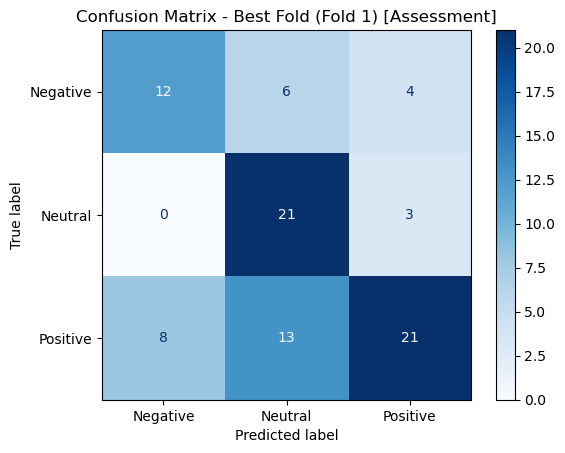


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.60      0.55      0.57        22
     Neutral       0.53      0.88      0.66        24
    Positive       0.75      0.50      0.60        42

    accuracy                           0.61        88
   macro avg       0.62      0.64      0.61        88
weighted avg       0.65      0.61      0.61        88


--- Processing Aspect: Content ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Content ---
  Best Hyperparameters: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 1}
  Average CV Accuracy: 0.7561
  Average CV AUC-ROC (OvR): 0.7748

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.7503
    Precision: 0.6512
    Recall   : 0.6866
    F1-Score : 0.6662

    --- Fold 2 ---
    Accuracy : 0.7567
    Precision: 0.6533
    Recall   : 0.6898
    F1-Score : 0.6686

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.750277,0.651188,0.686551,0.666249
1,2,0.756667,0.653291,0.689842,0.668623
2,3,0.768889,0.669453,0.699365,0.682692
3,4,0.756667,0.666241,0.707073,0.683561
4,5,0.747778,0.641091,0.683683,0.658110


  Average CV Accuracy: 0.7561 (+/- 0.0164)

  Best fold is Fold 4 with F1-Score = 0.6836


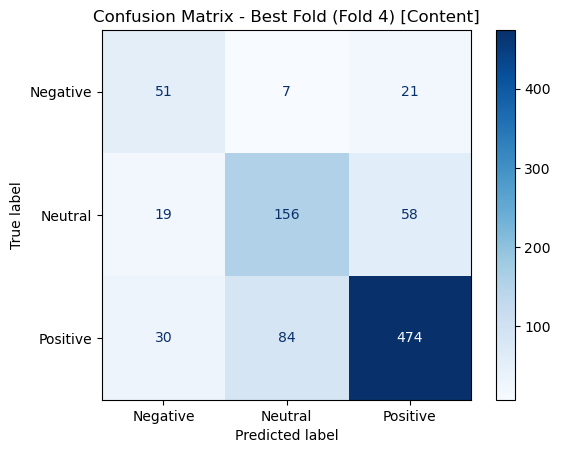


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.51      0.65      0.57        79
     Neutral       0.63      0.67      0.65       233
    Positive       0.86      0.81      0.83       588

    accuracy                           0.76       900
   macro avg       0.67      0.71      0.68       900
weighted avg       0.77      0.76      0.76       900


--- Processing Aspect: Instructor ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Instructor ---
  Best Hyperparameters: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 1}
  Average CV Accuracy: 0.7756
  Average CV AUC-ROC (OvR): 0.7720

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.7828
    Precision: 0.7546
    Recall   : 0.7105
    F1-Score : 0.7240

    --- Fold 2 ---
    Accuracy : 0.8235
    Precision: 0.7716
    Recall   : 0.7404
    F1-Score : 

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.782805,0.754593,0.710454,0.724036
1,2,0.823529,0.771582,0.740433,0.751445
2,3,0.773756,0.689757,0.685465,0.683728
3,4,0.728507,0.647544,0.655972,0.650104
4,5,0.769231,0.702381,0.682471,0.690546


  Average CV Accuracy: 0.7756 (+/- 0.0679)

  Best fold is Fold 2 with F1-Score = 0.7514


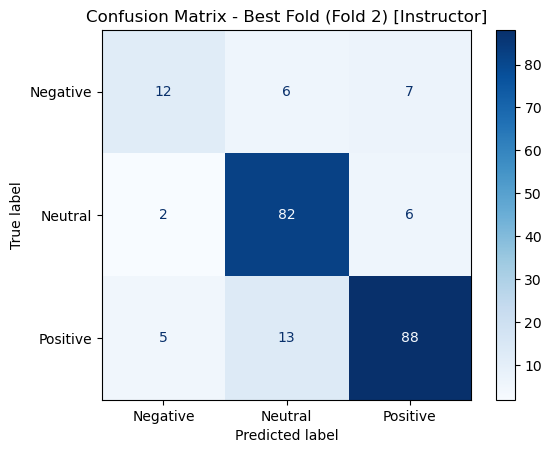


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.63      0.48      0.55        25
     Neutral       0.81      0.91      0.86        90
    Positive       0.87      0.83      0.85       106

    accuracy                           0.82       221
   macro avg       0.77      0.74      0.75       221
weighted avg       0.82      0.82      0.82       221


--- Processing Aspect: Interaction ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Interaction ---
  Best Hyperparameters: {'dt__criterion': 'entropy', 'dt__max_depth': None, 'dt__min_samples_leaf': 5}
  Average CV Accuracy: 0.5604
  Average CV AUC-ROC (OvR): 0.7648

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.4898
    Precision: 0.5532
    Recall   : 0.5639
    F1-Score : 0.4580

    --- Fold 2 ---
    Accuracy : 0.7143
    Precision: 0.6074
    Recall   : 0.5534
    F1-Sco

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.489796,0.553242,0.563933,0.458016
1,2,0.714286,0.607407,0.553379,0.562821
2,3,0.453608,0.484921,0.399386,0.395716
3,4,0.587629,0.637121,0.683948,0.553258
4,5,0.556701,0.582643,0.625576,0.516587


  Average CV Accuracy: 0.5604 (+/- 0.2021)

  Best fold is Fold 2 with F1-Score = 0.5628


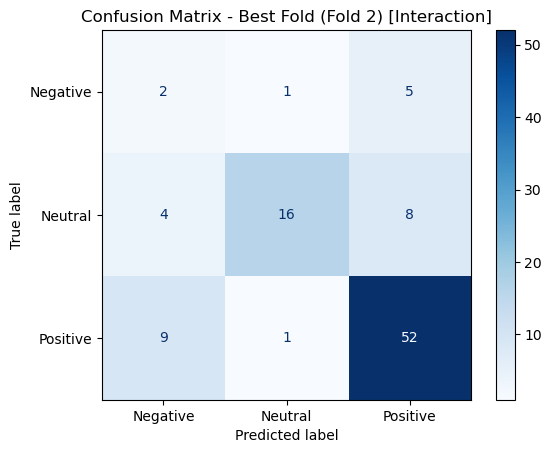


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.13      0.25      0.17         8
     Neutral       0.89      0.57      0.70        28
    Positive       0.80      0.84      0.82        62

    accuracy                           0.71        98
   macro avg       0.61      0.55      0.56        98
weighted avg       0.77      0.71      0.73        98


--- Processing Aspect: Structure ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Structure ---
  Best Hyperparameters: {'dt__criterion': 'entropy', 'dt__max_depth': None, 'dt__min_samples_leaf': 5}
  Average CV Accuracy: 0.6254
  Average CV AUC-ROC (OvR): 0.7682

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.6441
    Precision: 0.5988
    Recall   : 0.6137
    F1-Score : 0.5983

    --- Fold 2 ---
    Accuracy : 0.5847
    Precision: 0.5480
    Recall   : 0.5456
    F1-Score :

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.644068,0.598787,0.613715,0.598301
1,2,0.584746,0.548047,0.545574,0.532688
2,3,0.567797,0.546768,0.537879,0.521049
3,4,0.635593,0.551530,0.570549,0.551246
4,5,0.694915,0.625428,0.625473,0.625173


  Average CV Accuracy: 0.6254 (+/- 0.1013)

  Best fold is Fold 5 with F1-Score = 0.6252


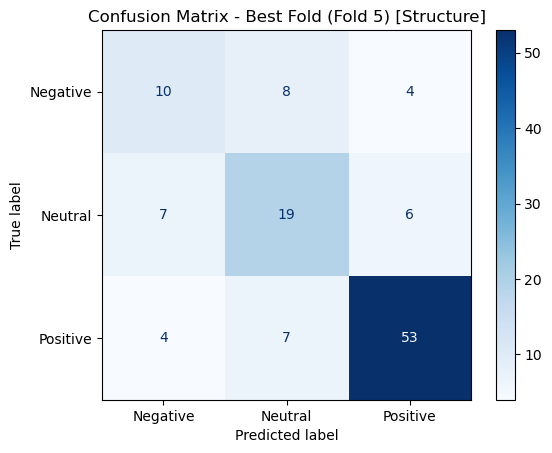


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.48      0.45      0.47        22
     Neutral       0.56      0.59      0.58        32
    Positive       0.84      0.83      0.83        64

    accuracy                           0.69       118
   macro avg       0.63      0.63      0.63       118
weighted avg       0.70      0.69      0.70       118


--- Decision Tree Training and Tuning Complete ---


In [7]:
# === Cell 7: Train and Tune Decision Tree Sentiment Models (with Class Weights) ===

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer, roc_auc_score
)
import matplotlib.pyplot as plt

print("--- Starting Decision Tree Sentiment Model Training & Tuning (with Class Weights) ---")

# --- Check if the development data is loaded ---
if 'df_dev' in locals() and 'X_dev' in locals():

    # Initialize dictionaries to store models and results
    dt_sentiment_models = {}
    dt_results = {}

    # List all unique aspects in the dev set
    aspect_labels = sorted(df_dev['Aspect_Label'].unique())
    print(f"Found aspects to train models for: {aspect_labels}\n")

    # Define hyperparameter grid for GridSearchCV
    param_grid = {
        'dt__criterion': ['gini', 'entropy'],
        'dt__max_depth': [None, 20],
        'dt__min_samples_leaf': [1, 5]
    }

    # Define ROC AUC scorer for multi-class
    roc_auc_scorer = make_scorer(roc_auc_score, needs_proba=True, multi_class='ovr', average='macro')

    # Loop through each aspect label
    for aspect in aspect_labels:
        print(f"\n--- Processing Aspect: {aspect} ---")

        # Filter dev data for this aspect only
        aspect_data_dev = df_dev[df_dev['Aspect_Label'] == aspect]
        X_aspect_dev = X_dev[aspect_data_dev.index]
        y_aspect_dev = aspect_data_dev['sentiment_label']

        # Skip aspect if too few samples
        if y_aspect_dev.value_counts().min() < 2:
            print(f"  [SKIPPING] Aspect '{aspect}' has a class with only 1 member. Cannot train model.")
            continue

        # Define pipeline: DecisionTree with class_weight=balanced
        pipeline = ImbPipeline([
            ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
        ])

        # Use Stratified K-Fold for fair splits
        k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Setup GridSearchCV to tune hyperparameters
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=k_fold,
            scoring={'accuracy': make_scorer(accuracy_score), 'roc_auc_ovr': roc_auc_scorer},
            refit='roc_auc_ovr',
            n_jobs=-1
        )

        try:
            # --- Run GridSearchCV ---
            print("  Running GridSearchCV...")
            grid_search.fit(X_aspect_dev, y_aspect_dev)
            print("  Grid search complete.")

            # Save best estimator
            best_model = grid_search.best_estimator_
            dt_sentiment_models[aspect] = best_model

            # Mean CV accuracy & AUC
            mean_cv_accuracy = grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_]
            mean_cv_auc = grid_search.cv_results_['mean_test_roc_auc_ovr'][grid_search.best_index_]

            # Save main results
            dt_results[aspect] = {
                'best_params': grid_search.best_params_,
                'mean_cv_accuracy': mean_cv_accuracy,
                'mean_cv_auc': mean_cv_auc
            }

            print(f"\n  --- GridSearchCV Results for Aspect: {aspect} ---")
            print(f"  Best Hyperparameters: {grid_search.best_params_}")
            print(f"  Average CV Accuracy: {mean_cv_accuracy:.4f}")
            print(f"  Average CV AUC-ROC (OvR): {mean_cv_auc:.4f}")

            # === Manual K-Fold using best hyperparameters to get detailed metrics ===
            print("\n  Evaluating Best Model with Detailed Fold Metrics...")

            fold_metrics = []
            fold_preds = []

            for fold_idx, (train_idx, test_idx) in enumerate(k_fold.split(X_aspect_dev, y_aspect_dev), 1):
                X_train, X_test = X_aspect_dev[train_idx], X_aspect_dev[test_idx]
                y_train, y_test = y_aspect_dev.iloc[train_idx], y_aspect_dev.iloc[test_idx]

                # Fit model using best hyperparameters found
                model = DecisionTreeClassifier(
                    criterion=grid_search.best_params_['dt__criterion'],
                    max_depth=grid_search.best_params_['dt__max_depth'],
                    min_samples_leaf=grid_search.best_params_['dt__min_samples_leaf'],
                    class_weight='balanced',
                    random_state=42
                )
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                # Calculate metrics for this fold
                acc = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
                rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
                f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

                # Save fold results
                fold_metrics.append({
                    'Fold': fold_idx,
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                    'F1-Score': f1
                })

                fold_preds.append({
                    'Fold': fold_idx,
                    'y_true': y_test,
                    'y_pred': y_pred
                })

                print(f"    --- Fold {fold_idx} ---")
                print(f"    Accuracy : {acc:.4f}")
                print(f"    Precision: {prec:.4f}")
                print(f"    Recall   : {rec:.4f}")
                print(f"    F1-Score : {f1:.4f}\n")

            # Convert to DataFrame for summary
            df_metrics = pd.DataFrame(fold_metrics)
            print("\n  === Detailed Fold Metrics ===")
            display(df_metrics)
            print("  Average CV Accuracy: {:.4f} (+/- {:.4f})".format(
                df_metrics['Accuracy'].mean(),
                df_metrics['Accuracy'].std() * 2
            ))

            dt_results[aspect] = {
                'best_params': grid_search.best_params_,
                'mean_cv_accuracy': mean_cv_accuracy,
                'mean_cv_auc': mean_cv_auc,
                'mean_cv_precision': df_metrics['Precision'].mean(),
                'mean_cv_recall': df_metrics['Recall'].mean(),
                'mean_cv_f1': df_metrics['F1-Score'].mean()
            }

            # === Identify and report best fold ===
            best_fold_idx = df_metrics['F1-Score'].idxmax()
            best_fold = fold_preds[best_fold_idx]

            print(f"\n  Best fold is Fold {best_fold['Fold']} with F1-Score = {df_metrics.loc[best_fold_idx, 'F1-Score']:.4f}")

            labels_present = np.unique(best_fold['y_true'])

            # These are already your sentiment names:
            sentiment_names = labels_present.tolist()
            
            # === Confusion Matrix ===
            cm = confusion_matrix(best_fold['y_true'], best_fold['y_pred'], labels=labels_present)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sentiment_names)
            disp.plot(cmap='Blues')
            plt.title(f'Confusion Matrix - Best Fold (Fold {best_fold["Fold"]}) [{aspect}]')
            plt.show()

            # === Classification report for best fold ===
            print("\n  === Classification Report for Best Fold ===")
            labels_present = np.unique(best_fold['y_true'])
            sentiment_names = labels_present.tolist()
            
            report = classification_report(
                best_fold['y_true'],
                best_fold['y_pred'],
                target_names=sentiment_names,
                digits=2,
                zero_division=0
            )
            print(report)

        except ValueError as ve:
            print(f"  [ERROR] A ValueError occurred for aspect '{aspect}'. Skipping.")
            print(f"  Error details: {ve}")

else:
    print("[ERROR] Development set ('df_dev', 'X_dev') not found.")

print("\n--- Decision Tree Training and Tuning Complete ---")

--- Starting SVM Sentiment Model Training & Tuning (with Class Weights) ---
Found aspects to train models for: ['Assessment', 'Content', 'Instructor', 'Interaction', 'Structure']


--- Processing Aspect: Assessment ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Assessment ---
  Best Hyperparameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Average CV Accuracy: 0.7203
  Average CV AUC-ROC (OvR): 0.9049

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.6818
    Precision: 0.7530
    Recall   : 0.6172
    F1-Score : 0.6375

    --- Fold 2 ---
    Accuracy : 0.7586
    Precision: 0.8608
    Recall   : 0.6763
    F1-Score : 0.6998

    --- Fold 3 ---
    Accuracy : 0.6667
    Precision: 0.7703
    Recall   : 0.5671
    F1-Score : 0.5896

    --- Fold 4 ---
    Accuracy : 0.7931
    Precision: 0.8679
    Recall   : 0.7295
    F1-Score : 0.7619

    --- Fold 5 ---
    Accuracy : 0.7011

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.681818,0.753021,0.617244,0.637463
1,2,0.758621,0.860812,0.676329,0.699845
2,3,0.666667,0.770276,0.567127,0.589642
3,4,0.793103,0.867938,0.729469,0.761869
4,5,0.701149,0.777778,0.648810,0.679875


  Average CV Accuracy: 0.7203 (+/- 0.1072)

  Best fold is Fold 4 with F1-Score = 0.7619


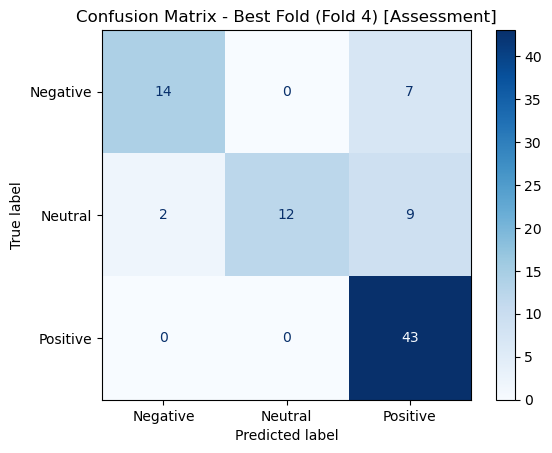


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.88      0.67      0.76        21
     Neutral       1.00      0.52      0.69        23
    Positive       0.73      1.00      0.84        43

    accuracy                           0.79        87
   macro avg       0.87      0.73      0.76        87
weighted avg       0.84      0.79      0.78        87


--- Processing Aspect: Content ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Content ---
  Best Hyperparameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Average CV Accuracy: 0.8243
  Average CV AUC-ROC (OvR): 0.9146

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.8147
    Precision: 0.8476
    Recall   : 0.6715
    F1-Score : 0.7279

    --- Fold 2 ---
    Accuracy : 0.8156
    Precision: 0.8212
    Recall   : 0.6730
    F1-Score : 0.7208

    --- Fold 3

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.814650,0.847619,0.671528,0.727937
1,2,0.815556,0.821172,0.673022,0.720797
2,3,0.833333,0.845160,0.677655,0.727926
3,4,0.822222,0.835896,0.694494,0.744555
4,5,0.835556,0.847024,0.690808,0.742147


  Average CV Accuracy: 0.8243 (+/- 0.0195)

  Best fold is Fold 4 with F1-Score = 0.7446


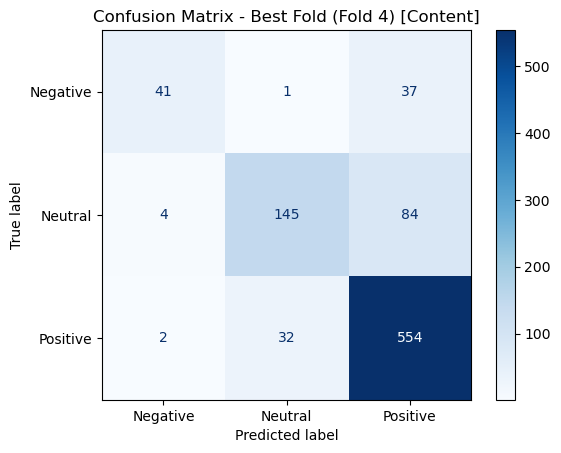


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.87      0.52      0.65        79
     Neutral       0.81      0.62      0.71       233
    Positive       0.82      0.94      0.88       588

    accuracy                           0.82       900
   macro avg       0.84      0.69      0.74       900
weighted avg       0.82      0.82      0.81       900


--- Processing Aspect: Instructor ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Instructor ---
  Best Hyperparameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Average CV Accuracy: 0.8109
  Average CV AUC-ROC (OvR): 0.9356

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.8145
    Precision: 0.8965
    Recall   : 0.6765
    F1-Score : 0.7101

    --- Fold 2 ---
    Accuracy : 0.8552
    Precision: 0.9124
    Recall   : 0.7382
    F1-Score : 0.7777

    --- 

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.814480,0.896467,0.676492,0.710135
1,2,0.855204,0.912415,0.738155,0.777651
2,3,0.809955,0.846273,0.674465,0.703754
3,4,0.791855,0.794805,0.666765,0.693104
4,5,0.782805,0.844275,0.677424,0.713956


  Average CV Accuracy: 0.8109 (+/- 0.0559)

  Best fold is Fold 2 with F1-Score = 0.7777


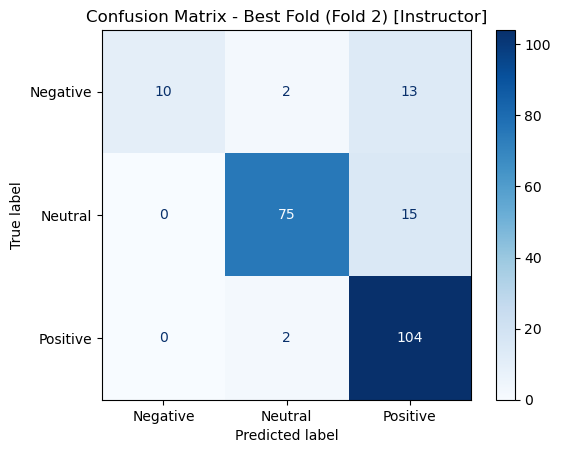


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       1.00      0.40      0.57        25
     Neutral       0.95      0.83      0.89        90
    Positive       0.79      0.98      0.87       106

    accuracy                           0.86       221
   macro avg       0.91      0.74      0.78       221
weighted avg       0.88      0.86      0.85       221


--- Processing Aspect: Interaction ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Interaction ---
  Best Hyperparameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Average CV Accuracy: 0.8029
  Average CV AUC-ROC (OvR): 0.9047

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.7857
    Precision: 0.8965
    Recall   : 0.5425
    F1-Score : 0.5814

    --- Fold 2 ---
    Accuracy : 0.8163
    Precision: 0.8974
    Recall   : 0.5839
    F1-Score : 0.6166

    --

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.785714,0.896477,0.542549,0.581354
1,2,0.816327,0.897403,0.583909,0.616640
2,3,0.742268,0.544771,0.458909,0.459977
3,4,0.824742,0.890619,0.638633,0.692840
4,5,0.845361,0.910336,0.655914,0.711111


  Average CV Accuracy: 0.8029 (+/- 0.0802)

  Best fold is Fold 5 with F1-Score = 0.7111


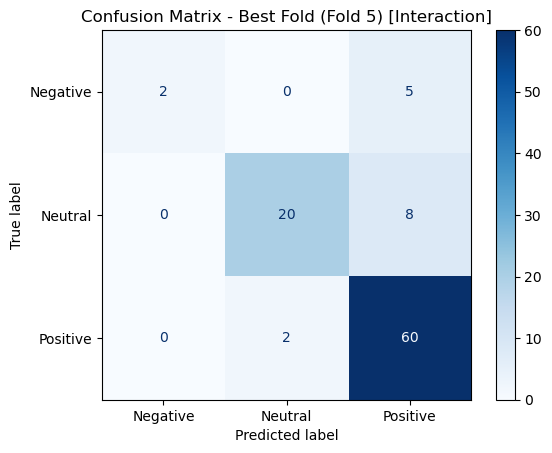


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       1.00      0.29      0.44         7
     Neutral       0.91      0.71      0.80        28
    Positive       0.82      0.97      0.89        62

    accuracy                           0.85        97
   macro avg       0.91      0.66      0.71        97
weighted avg       0.86      0.85      0.83        97


--- Processing Aspect: Structure ---
  Running GridSearchCV...
  Grid search complete.

  --- GridSearchCV Results for Aspect: Structure ---
  Best Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Average CV Accuracy: 0.7390
  Average CV AUC-ROC (OvR): 0.8955

  Evaluating Best Model with Detailed Fold Metrics...
    --- Fold 1 ---
    Accuracy : 0.7034
    Precision: 0.7805
    Recall   : 0.6139
    F1-Score : 0.6361

    --- Fold 2 ---
    Accuracy : 0.7627
    Precision: 0.8155
    Recall   : 0.6584
    F1-Score : 0.6792

    --- Fol

,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.703390,0.780497,0.613918,0.636080
1,2,0.762712,0.815539,0.658387,0.679210
2,3,0.754237,0.745851,0.677557,0.697015
3,4,0.728814,0.756790,0.625947,0.655452
4,5,0.745763,0.789712,0.651989,0.684753


  Average CV Accuracy: 0.7390 (+/- 0.0470)

  Best fold is Fold 3 with F1-Score = 0.6970


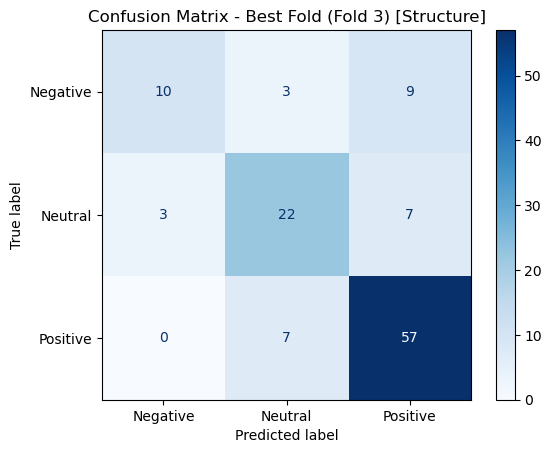


  === Classification Report for Best Fold ===
              precision    recall  f1-score   support

    Negative       0.77      0.45      0.57        22
     Neutral       0.69      0.69      0.69        32
    Positive       0.78      0.89      0.83        64

    accuracy                           0.75       118
   macro avg       0.75      0.68      0.70       118
weighted avg       0.75      0.75      0.74       118


--- SVM Training and Tuning Complete ---


In [8]:
# === Cell 8: Train and Tune SVM Sentiment Models (with Class Weights) ===

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, make_scorer, roc_auc_score, classification_report
)
import matplotlib.pyplot as plt

print("--- Starting SVM Sentiment Model Training & Tuning (with Class Weights) ---")

# --- Check if dev set exists ---
if 'df_dev' in locals() and 'X_dev' in locals():

    # Dictionaries to store final models and results
    svm_sentiment_models = {}
    svm_results = {}

    # List of unique aspect labels
    aspect_labels = sorted(df_dev['Aspect_Label'].unique())
    print(f"Found aspects to train models for: {aspect_labels}\n")

    # --- Define parameter grid for GridSearchCV ---
    param_grid = [
        {'svm__C': [1, 10], 'svm__kernel': ['rbf'], 'svm__gamma': ['scale']},
        {'svm__C': [0.1, 1], 'svm__kernel': ['linear']}
    ]

    # Define custom ROC AUC scorer
    roc_auc_scorer = make_scorer(roc_auc_score, needs_proba=True, multi_class='ovr', average='macro')

    # --- Loop through each aspect to train individual models ---
    for aspect in aspect_labels:
        print(f"\n--- Processing Aspect: {aspect} ---")

        # Filter development set for current aspect
        aspect_data_dev = df_dev[df_dev['Aspect_Label'] == aspect]
        X_aspect_dev = X_dev[aspect_data_dev.index]
        y_aspect_dev = aspect_data_dev['sentiment_label']

        # Skip if not enough classes
        if y_aspect_dev.value_counts().min() < 2:
            print(f"  [SKIPPED] Aspect '{aspect}' has a class with only 1 member. Cannot train model.")
            continue

        # Define pipeline with SVM model and class weight balancing
        pipeline = ImbPipeline([
            ('svm', SVC(probability=True, random_state=42, class_weight='balanced'))
        ])

        # Stratified K-Fold for fair splits
        k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Setup GridSearchCV with accuracy and ROC AUC
        grid_search_svm = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=k_fold,
            scoring={'accuracy': make_scorer(accuracy_score), 'roc_auc_ovr': roc_auc_scorer},
            refit='roc_auc_ovr',
            n_jobs=-1
        )

        try:
            # --- Run GridSearchCV ---
            print("  Running GridSearchCV...")
            grid_search_svm.fit(X_aspect_dev, y_aspect_dev)
            print("  Grid search complete.")

            # Store best estimator
            best_model_svm = grid_search_svm.best_estimator_
            svm_sentiment_models[aspect] = best_model_svm

            # Get mean accuracy and AUC
            mean_cv_accuracy_svm = grid_search_svm.cv_results_['mean_test_accuracy'][grid_search_svm.best_index_]
            mean_cv_auc_svm = grid_search_svm.cv_results_['mean_test_roc_auc_ovr'][grid_search_svm.best_index_]

            # Save results
            svm_results[aspect] = {
                'best_params': grid_search_svm.best_params_,
                'mean_cv_accuracy': mean_cv_accuracy_svm,
                'mean_cv_auc': mean_cv_auc_svm
            }

            print(f"\n  --- GridSearchCV Results for Aspect: {aspect} ---")
            print(f"  Best Hyperparameters: {grid_search_svm.best_params_}")
            print(f"  Average CV Accuracy: {mean_cv_accuracy_svm:.4f}")
            print(f"  Average CV AUC-ROC (OvR): {mean_cv_auc_svm:.4f}")

            # === Manual K-Fold to display detailed metrics for each fold ===
            print("\n  Evaluating Best Model with Detailed Fold Metrics...")

            fold_metrics = []
            fold_preds = []

            for fold_idx, (train_idx, test_idx) in enumerate(k_fold.split(X_aspect_dev, y_aspect_dev), 1):
                X_train, X_test = X_aspect_dev[train_idx], X_aspect_dev[test_idx]
                y_train, y_test = y_aspect_dev.iloc[train_idx], y_aspect_dev.iloc[test_idx]

                # Use best hyperparameters to fit model
                model = SVC(
                    probability=True,
                    C=grid_search_svm.best_params_['svm__C'],
                    kernel=grid_search_svm.best_params_['svm__kernel'],
                    gamma=grid_search_svm.best_params_.get('svm__gamma', 'scale'),
                    class_weight='balanced',
                    random_state=42
                )
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                # Calculate metrics
                acc = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
                rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
                f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

                # Store fold results
                fold_metrics.append({
                    'Fold': fold_idx,
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                    'F1-Score': f1
                })

                fold_preds.append({
                    'Fold': fold_idx,
                    'y_true': y_test,
                    'y_pred': y_pred
                })

                print(f"    --- Fold {fold_idx} ---")
                print(f"    Accuracy : {acc:.4f}")
                print(f"    Precision: {prec:.4f}")
                print(f"    Recall   : {rec:.4f}")
                print(f"    F1-Score : {f1:.4f}\n")

            # Create DataFrame for folds
            df_metrics = pd.DataFrame(fold_metrics)
            print("\n  === Detailed Fold Metrics ===")
            display(df_metrics)
            print("  Average CV Accuracy: {:.4f} (+/- {:.4f})".format(
                df_metrics['Accuracy'].mean(),
                df_metrics['Accuracy'].std() * 2
            ))

            svm_results[aspect] = {
                'best_params': grid_search_svm.best_params_,
                'mean_cv_accuracy': mean_cv_accuracy_svm,
                'mean_cv_auc': mean_cv_auc_svm,
                'mean_cv_precision': df_metrics['Precision'].mean(),
                'mean_cv_recall': df_metrics['Recall'].mean(),
                'mean_cv_f1': df_metrics['F1-Score'].mean()
            }

            # === Identify best fold ===
            best_fold_idx = df_metrics['F1-Score'].idxmax()
            best_fold = fold_preds[best_fold_idx]
            print(f"\n  Best fold is Fold {best_fold['Fold']} with F1-Score = {df_metrics.loc[best_fold_idx, 'F1-Score']:.4f}")
            
            # === Confusion Matrix for best fold ===
            labels_present = np.unique(best_fold['y_true'])
            sentiment_names = labels_present.tolist()
            
            cm = confusion_matrix(best_fold['y_true'], best_fold['y_pred'], labels=labels_present)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sentiment_names)
            disp.plot(cmap='Blues')
            plt.title(f'Confusion Matrix - Best Fold (Fold {best_fold["Fold"]}) [{aspect}]')
            plt.show()
            
            # === Classification Report for best fold ===
            print("\n  === Classification Report for Best Fold ===")
            report = classification_report(
                best_fold['y_true'],
                best_fold['y_pred'],
                target_names=sentiment_names,
                digits=2,
                zero_division=0
            )
            print(report)

        except ValueError as ve:
            print(f"  [ERROR] A ValueError occurred for aspect '{aspect}'. Skipping.")
            print(f"  Error details: {ve}")

else:
    print("[ERROR] Development set ('df_dev', 'X_dev') not found.")

print("\n--- SVM Training and Tuning Complete ---")

--- Starting Hybrid Model Evaluation ---

--- Part 1: Searching for Optimal Hybrid Weights ---

--- Aspect: Assessment ---
Trying weights (DT | SVM):
  DT: 1.0 | SVM: 0.0 → F1: 0.5672 | Accuracy: 0.5725
  DT: 0.9 | SVM: 0.1 → F1: 0.5886 | Accuracy: 0.5954
  DT: 0.8 | SVM: 0.2 → F1: 0.6554 | Accuracy: 0.6641
  DT: 0.7 | SVM: 0.3 → F1: 0.6584 | Accuracy: 0.6718
  DT: 0.6 | SVM: 0.4 → F1: 0.6733 | Accuracy: 0.7023
  DT: 0.5 | SVM: 0.5 → F1: 0.7105 | Accuracy: 0.7405
  DT: 0.4 | SVM: 0.6 → F1: 0.7143 | Accuracy: 0.7481
  DT: 0.3 | SVM: 0.7 → F1: 0.7162 | Accuracy: 0.7481
  DT: 0.2 | SVM: 0.8 → F1: 0.7108 | Accuracy: 0.7481
  DT: 0.1 | SVM: 0.9 → F1: 0.7206 | Accuracy: 0.7557
  DT: 0.0 | SVM: 1.0 → F1: 0.7414 | Accuracy: 0.7710
>>> Best weights for 'Assessment': DT = 0.00, SVM = 1.00 (F1 = 0.7414, Acc = 0.7710)

--- Aspect: Content ---
Trying weights (DT | SVM):
  DT: 1.0 | SVM: 0.0 → F1: 0.6323 | Accuracy: 0.7269
  DT: 0.9 | SVM: 0.1 → F1: 0.6323 | Accuracy: 0.7269
  DT: 0.8 | SVM: 0.2 → F

,DT,SVM
Assessment,0.0,1.0
Content,0.0,1.0
Instructor,0.1,0.9
Interaction,0.0,1.0
Structure,0.2,0.8



--- Part 2: Evaluating Final Hybrid Model with 5-Fold Cross-Validation ---

--- Evaluating Hybrid for Aspect: Assessment ---
  Using weights: DT=0.00, SVM=1.00
    --- Fold 1 ---
    Accuracy : 0.7500
    Precision: 0.7500
    Recall   : 0.7226
    F1-Score : 0.7328

    --- Fold 2 ---
    Accuracy : 0.7816
    Precision: 0.7968
    Recall   : 0.7311
    F1-Score : 0.7509

    --- Fold 3 ---
    Accuracy : 0.7356
    Precision: 0.7399
    Recall   : 0.6677
    F1-Score : 0.6864

    --- Fold 4 ---
    Accuracy : 0.7816
    Precision: 0.8214
    Recall   : 0.7393
    F1-Score : 0.7458

    --- Fold 5 ---
    Accuracy : 0.7586
    Precision: 0.7385
    Recall   : 0.7500
    F1-Score : 0.7355


  === Detailed Fold Metrics ===


,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.750000,0.750000,0.722583,0.732756
1,2,0.781609,0.796810,0.731058,0.750867
2,3,0.735632,0.739881,0.667726,0.686351
3,4,0.781609,0.821438,0.739339,0.745751
4,5,0.758621,0.738475,0.750000,0.735455


  Average CV Accuracy: 0.7615 (+/- 0.0402)

  Best fold is Fold 2 with F1-Score = 0.7509


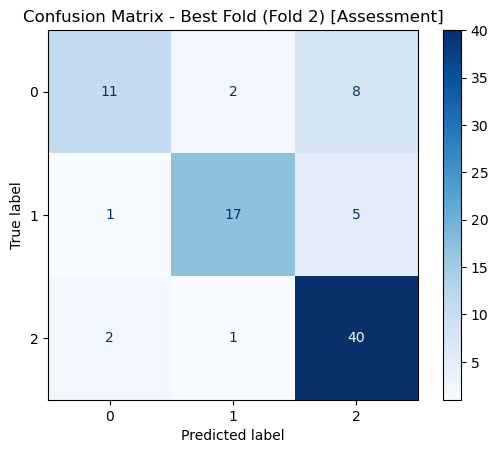


--- Evaluating Hybrid for Aspect: Content ---
  Using weights: DT=0.00, SVM=1.00
    --- Fold 1 ---
    Accuracy : 0.8147
    Precision: 0.8259
    Recall   : 0.6868
    F1-Score : 0.7362

    --- Fold 2 ---
    Accuracy : 0.8167
    Precision: 0.8052
    Recall   : 0.6809
    F1-Score : 0.7243

    --- Fold 3 ---
    Accuracy : 0.8322
    Precision: 0.8188
    Recall   : 0.6844
    F1-Score : 0.7292

    --- Fold 4 ---
    Accuracy : 0.8256
    Precision: 0.8108
    Recall   : 0.7145
    F1-Score : 0.7523

    --- Fold 5 ---
    Accuracy : 0.8378
    Precision: 0.8087
    Recall   : 0.7119
    F1-Score : 0.7496


  === Detailed Fold Metrics ===


,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.814650,0.825890,0.686802,0.736156
1,2,0.816667,0.805169,0.680895,0.724281
2,3,0.832222,0.818760,0.684393,0.729238
3,4,0.825556,0.810832,0.714457,0.752304
4,5,0.837778,0.808728,0.711931,0.749619


  Average CV Accuracy: 0.8254 (+/- 0.0198)

  Best fold is Fold 4 with F1-Score = 0.7523


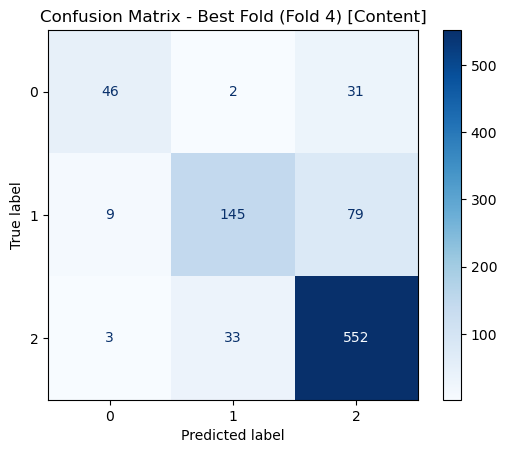


--- Evaluating Hybrid for Aspect: Instructor ---
  Using weights: DT=0.10, SVM=0.90
    --- Fold 1 ---
    Accuracy : 0.8281
    Precision: 0.8576
    Recall   : 0.7085
    F1-Score : 0.7415

    --- Fold 2 ---
    Accuracy : 0.8507
    Precision: 0.8369
    Recall   : 0.7356
    F1-Score : 0.7636

    --- Fold 3 ---
    Accuracy : 0.8009
    Precision: 0.7543
    Recall   : 0.6789
    F1-Score : 0.6987

    --- Fold 4 ---
    Accuracy : 0.8145
    Precision: 0.8070
    Recall   : 0.7514
    F1-Score : 0.7714

    --- Fold 5 ---
    Accuracy : 0.7964
    Precision: 0.7831
    Recall   : 0.6989
    F1-Score : 0.7232


  === Detailed Fold Metrics ===


,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.828054,0.857605,0.708539,0.741493
1,2,0.850679,0.836884,0.735570,0.763580
2,3,0.800905,0.754301,0.678924,0.698717
3,4,0.814480,0.807037,0.751420,0.771358
4,5,0.796380,0.783087,0.698937,0.723214


  Average CV Accuracy: 0.8181 (+/- 0.0441)

  Best fold is Fold 4 with F1-Score = 0.7714


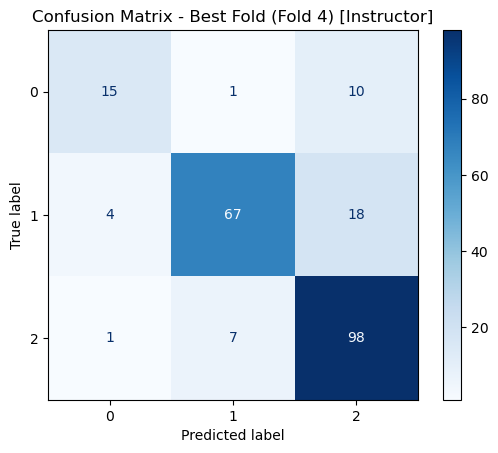


--- Evaluating Hybrid for Aspect: Interaction ---
  Using weights: DT=0.00, SVM=1.00
    --- Fold 1 ---
    Accuracy : 0.7959
    Precision: 0.8870
    Recall   : 0.5619
    F1-Score : 0.5975

    --- Fold 2 ---
    Accuracy : 0.8367
    Precision: 0.8911
    Recall   : 0.6142
    F1-Score : 0.6367

    --- Fold 3 ---
    Accuracy : 0.7320
    Precision: 0.8134
    Recall   : 0.5023
    F1-Score : 0.5353

    --- Fold 4 ---
    Accuracy : 0.8041
    Precision: 0.6585
    Recall   : 0.6475
    F1-Score : 0.6526

    --- Fold 5 ---
    Accuracy : 0.8557
    Precision: 0.9155
    Recall   : 0.6678
    F1-Score : 0.7212


  === Detailed Fold Metrics ===


,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.795918,0.887014,0.561949,0.597496
1,2,0.836735,0.891111,0.614247,0.636732
2,3,0.731959,0.813353,0.502304,0.535343
3,4,0.804124,0.658539,0.647465,0.652557
4,5,0.855670,0.915459,0.667819,0.721165


  Average CV Accuracy: 0.8049 (+/- 0.0948)

  Best fold is Fold 5 with F1-Score = 0.7212


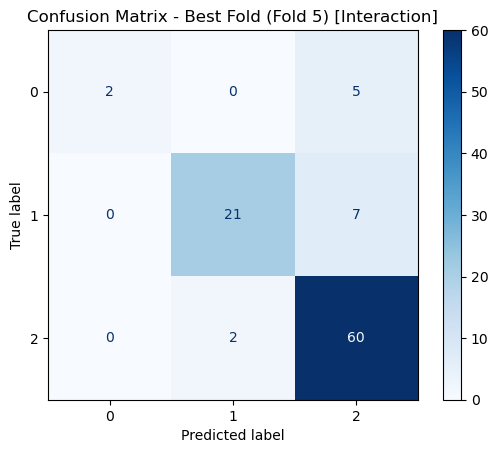


--- Evaluating Hybrid for Aspect: Structure ---
  Using weights: DT=0.20, SVM=0.80
    --- Fold 1 ---
    Accuracy : 0.7119
    Precision: 0.7491
    Recall   : 0.6391
    F1-Score : 0.6619

    --- Fold 2 ---
    Accuracy : 0.8051
    Precision: 0.8418
    Recall   : 0.7376
    F1-Score : 0.7635

    --- Fold 3 ---
    Accuracy : 0.7881
    Precision: 0.7688
    Recall   : 0.7386
    F1-Score : 0.7496

    --- Fold 4 ---
    Accuracy : 0.7373
    Precision: 0.7272
    Recall   : 0.6510
    F1-Score : 0.6748

    --- Fold 5 ---
    Accuracy : 0.7881
    Precision: 0.7832
    Recall   : 0.7135
    F1-Score : 0.7360


  === Detailed Fold Metrics ===


,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.711864,0.749126,0.639093,0.661877
1,2,0.805085,0.841810,0.737584,0.763480
2,3,0.788136,0.768803,0.738636,0.749634
3,4,0.737288,0.727193,0.651042,0.674754
4,5,0.788136,0.783226,0.713542,0.736040


  Average CV Accuracy: 0.7661 (+/- 0.0791)

  Best fold is Fold 2 with F1-Score = 0.7635


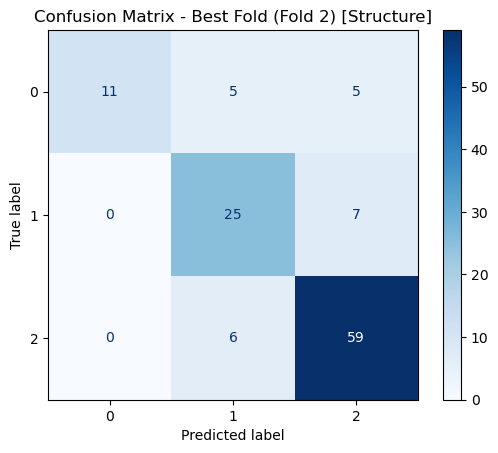

In [9]:
# === Cell 9: Hybrid Model Weight Calculation and Evaluation ===

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

print("--- Starting Hybrid Model Evaluation ---")

# Ensure all necessary components from previous cells are available
if 'df_dev' in locals() and 'dt_sentiment_models' in locals() and 'svm_sentiment_models' in locals():

    # --- Part 1: Find Optimal Weights for Each Aspect ---
    print("\n--- Part 1: Searching for Optimal Hybrid Weights ---")
    hybrid_sentiment_weights = {}
    aspect_labels = sorted(df_dev['Aspect_Label'].unique())
    
    for aspect in aspect_labels:
        print(f"\n--- Aspect: {aspect} ---")
        
        aspect_data = df_dev[df_dev['Aspect_Label'] == aspect]
        X_aspect = X_dev[aspect_data.index]
        y_aspect = aspect_data['sentiment_label']
    
        if len(y_aspect.unique()) < 2:
            print(f"[SKIPPED] Not enough classes for '{aspect}'")
            hybrid_sentiment_weights[aspect] = {'DT': 0.5, 'SVM': 0.5}
            continue
    
        # Split into train and validation
        X_train_w, X_val_w, y_train_w, y_val_w = train_test_split(
            X_aspect, y_aspect, test_size=0.3, random_state=42, stratify=y_aspect)
    
        dt_model = dt_sentiment_models[aspect]
        svm_model = svm_sentiment_models[aspect]
    
        # Fit them on the training split
        dt_model.fit(X_train_w, y_train_w)
        svm_model.fit(X_train_w, y_train_w)
    
        prob_dt = dt_model.predict_proba(X_val_w)
        prob_svm = svm_model.predict_proba(X_val_w)
        class_order = svm_model.classes_
    
        best_f1 = -1
        best_acc = -1
        best_weights = (0.5, 0.5)
    
        print("Trying weights (DT | SVM):")
        for w_svm in np.linspace(0.0, 1.0, 11):
            w_dt = 1.0 - w_svm
            avg_prob = w_dt * prob_dt + w_svm * prob_svm
            y_pred = class_order[np.argmax(avg_prob, axis=1)]
    
            f1 = f1_score(y_val_w, y_pred, average='macro', zero_division=0)
            acc = accuracy_score(y_val_w, y_pred)
    
            print(f"  DT: {w_dt:.1f} | SVM: {w_svm:.1f} → F1: {f1:.4f} | Accuracy: {acc:.4f}")
    
            if f1 > best_f1:
                best_f1 = f1
                best_acc = acc
                best_weights = (w_dt, w_svm)
    
        hybrid_sentiment_weights[aspect] = {'DT': round(best_weights[0], 2), 'SVM': round(best_weights[1], 2)}
        print(f">>> Best weights for '{aspect}': DT = {best_weights[0]:.2f}, SVM = {best_weights[1]:.2f} (F1 = {best_f1:.4f}, Acc = {best_acc:.4f})")
    
    print("\n--- Optimal Weights Found ---")
    display(pd.DataFrame.from_dict(hybrid_sentiment_weights, orient='index'))

    print("\n--- Part 2: Evaluating Final Hybrid Model with 5-Fold Cross-Validation ---")
    hybrid_results = {}
    
    for aspect in aspect_labels:
        print(f"\n--- Evaluating Hybrid for Aspect: {aspect} ---")
        w_dt = hybrid_sentiment_weights[aspect]['DT']
        w_svm = hybrid_sentiment_weights[aspect]['SVM']
        print(f"  Using weights: DT={w_dt:.2f}, SVM={w_svm:.2f}")
    
        aspect_data_dev = df_dev[df_dev['Aspect_Label'] == aspect]
        X_aspect_dev = X_dev[aspect_data_dev.index]
        y_aspect_dev = aspect_data_dev['sentiment_label']
    
        if len(y_aspect_dev.unique()) < 2:
            print("  Skipping K-Fold evaluation due to insufficient classes.")
            continue
    
        k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        fold_metrics = []
        fold_preds = []
    
        for fold_idx, (train_idx, test_idx) in enumerate(k_fold.split(X_aspect_dev, y_aspect_dev), 1):
            X_train, X_test = X_aspect_dev[train_idx], X_aspect_dev[test_idx]
            y_train, y_test = y_aspect_dev.iloc[train_idx], y_aspect_dev.iloc[test_idx]
    
            dt_model = dt_sentiment_models[aspect]
            svm_model = svm_sentiment_models[aspect]
    
            dt_model.fit(X_train, y_train)
            svm_model.fit(X_train, y_train)
    
            prob_dt = dt_model.predict_proba(X_test)
            prob_svm = svm_model.predict_proba(X_test)
    
            avg_prob = w_dt * prob_dt + w_svm * prob_svm
            y_pred = dt_model.classes_[np.argmax(avg_prob, axis=1)]
    
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
            rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
            fold_metrics.append({
                'Fold': fold_idx,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1
            })
    
            fold_preds.append({
                'Fold': fold_idx,
                'y_true': y_test,
                'y_pred': y_pred
            })
    
            print(f"    --- Fold {fold_idx} ---")
            print(f"    Accuracy : {acc:.4f}")
            print(f"    Precision: {prec:.4f}")
            print(f"    Recall   : {rec:.4f}")
            print(f"    F1-Score : {f1:.4f}\n")
    
        df_metrics = pd.DataFrame(fold_metrics)
        hybrid_results[aspect] = {
            'mean_cv_accuracy': df_metrics['Accuracy'].mean(),
            'mean_cv_precision': df_metrics['Precision'].mean(),
            'mean_cv_recall': df_metrics['Recall'].mean(),
            'mean_cv_f1': df_metrics['F1-Score'].mean()
        }

        print("\n  === Detailed Fold Metrics ===")
        display(df_metrics)
        print("  Average CV Accuracy: {:.4f} (+/- {:.4f})".format(
            df_metrics['Accuracy'].mean(),
            df_metrics['Accuracy'].std() * 2
        ))
    
        # Find best fold for confusion matrix
        best_fold_idx = df_metrics['F1-Score'].idxmax()
        best_fold = fold_preds[best_fold_idx]
    
        print(f"\n  Best fold is Fold {best_fold['Fold']} with F1-Score = {df_metrics.loc[best_fold_idx, 'F1-Score']:.4f}")
    
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
        import matplotlib.pyplot as plt
    
        cm = confusion_matrix(best_fold['y_true'], best_fold['y_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix - Best Fold (Fold {best_fold["Fold"]}) [{aspect}]')
        plt.show()
    
        # Save final hybrid results for this aspect
        hybrid_results[aspect] = {
            'mean_cv_accuracy': df_metrics['Accuracy'].mean(),
            'mean_cv_precision': df_metrics['Precision'].mean(),
            'mean_cv_recall': df_metrics['Recall'].mean(),
            'mean_cv_f1': df_metrics['F1-Score'].mean()
        }

In [10]:
# === Cell 10: Find Optimal Thresholds for Sentiment Classification ===

import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report
import joblib

print("--- Starting Optimal Threshold Search ---")

# === 1. Load or confirm the fitted aspect extraction model ===
try:
    aspect_model = joblib.load("aspect_extraction_model.joblib")
except NameError:
    print("[INFO] Aspect extraction model not found in memory. Loading from file...")
    aspect_model = joblib.load("aspect_extraction_model.joblib")
    print("[SUCCESS] Loaded fitted aspect extraction model.")

# === 2. Prepare data ===
X_train_full = X_dev
y_train_full = y_sentiment_dev

# Use the aspect predictions to choose which hybrid weights to apply per text
y_aspect_pred_dev_for_senti = aspect_model.predict(X_train_full)

# Get sentiment classes from one of the trained SVMs
sentiment_classes_dev = svm_sentiment_models[aspect_labels[0]].classes_

# === 3. Get Hybrid Probabilities ===
y_sentiment_proba_dev = []
for i in range(X_train_full.shape[0]):
    predicted_aspect = y_aspect_pred_dev_for_senti[i]
    text_vector = X_train_full[i]

    dt_model = dt_sentiment_models[predicted_aspect]
    svm_model = svm_sentiment_models[predicted_aspect]
    weights = hybrid_sentiment_weights[predicted_aspect]

    prob_dt = dt_model.predict_proba(text_vector)[0]
    prob_svm = svm_model.predict_proba(text_vector)[0]

    avg_prob = weights['DT'] * prob_dt + weights['SVM'] * prob_svm
    y_sentiment_proba_dev.append(avg_prob)

y_sentiment_proba_dev = np.array(y_sentiment_proba_dev)

# === 4. Find Best Threshold per Class ===
optimal_thresholds = {}
y_train_true_df = pd.get_dummies(y_train_full)

print("\nSearching for best F1-score threshold for each class...")
threshold_results = []

for i, class_name in enumerate(sentiment_classes_dev):
    best_threshold = 0.5
    best_f1 = 0.0

    print(f"\n--- Class: {class_name} ---")

    for threshold in np.arange(0.05, 1.0, 0.01):
        y_pred_at_threshold = (y_sentiment_proba_dev[:, i] > threshold).astype(int)
        f1 = f1_score(y_train_true_df[class_name], y_pred_at_threshold, zero_division=0)

        print(f"  Threshold: {threshold:.2f} → F1-score: {f1:.4f}")

        threshold_results.append({
            'Class': class_name,
            'Threshold': threshold,
            'F1': f1
        })

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    optimal_thresholds[class_name] = best_threshold
    print(f">>> Best for '{class_name}': Threshold = {best_threshold:.2f} (F1 = {best_f1:.4f})")

print("\n--- Optimal Thresholds Found ---")
print(optimal_thresholds)

# Optional: Display search results
df_thresholds = pd.DataFrame(threshold_results)
display(df_thresholds)

# === 5. Generate Final Hybrid Predictions using Thresholds ===
print("\n--- Final Hybrid Model Classification Report ---")

y_sentiment_preds = []
for i in range(X_dev.shape[0]):
    predicted_aspect = y_aspect_pred_dev_for_senti[i]
    text_vector = X_dev[i]

    dt_model = dt_sentiment_models[predicted_aspect]
    svm_model = svm_sentiment_models[predicted_aspect]
    weights = hybrid_sentiment_weights[predicted_aspect]

    prob_dt = dt_model.predict_proba(text_vector)[0]
    prob_svm = svm_model.predict_proba(text_vector)[0]
    avg_prob = weights['DT'] * prob_dt + weights['SVM'] * prob_svm

    final_class = None
    for j, class_name in enumerate(sentiment_classes_dev):
        threshold = optimal_thresholds[class_name]
        if avg_prob[j] >= threshold:
            final_class = class_name
            break

    if final_class is None:
        final_class = sentiment_classes_dev[np.argmax(avg_prob)]

    y_sentiment_preds.append(final_class)

# === 6. Classification Report ===
labels_present = np.unique(y_sentiment_dev)
sentiment_names = []
for val in labels_present:
    if val == -1:
        sentiment_names.append("Negative")
    elif val == 0:
        sentiment_names.append("Neutral")
    elif val == 1:
        sentiment_names.append("Positive")
    else:
        sentiment_names.append(str(val))

report = classification_report(
    y_sentiment_dev,
    y_sentiment_preds,
    target_names=sentiment_names,
    digits=2,
    zero_division=0
)

print(report)

--- Starting Optimal Threshold Search ---

Searching for best F1-score threshold for each class...

--- Class: Negative ---
  Threshold: 0.05 → F1-score: 0.6667
  Threshold: 0.06 → F1-score: 0.6975
  Threshold: 0.07 → F1-score: 0.7215
  Threshold: 0.08 → F1-score: 0.7594
  Threshold: 0.09 → F1-score: 0.7859
  Threshold: 0.10 → F1-score: 0.8022
  Threshold: 0.11 → F1-score: 0.8060
  Threshold: 0.12 → F1-score: 0.8141
  Threshold: 0.13 → F1-score: 0.8228
  Threshold: 0.14 → F1-score: 0.8281
  Threshold: 0.15 → F1-score: 0.8316
  Threshold: 0.16 → F1-score: 0.8422
  Threshold: 0.17 → F1-score: 0.8422
  Threshold: 0.18 → F1-score: 0.8445
  Threshold: 0.19 → F1-score: 0.8502
  Threshold: 0.20 → F1-score: 0.8545
  Threshold: 0.21 → F1-score: 0.8580
  Threshold: 0.22 → F1-score: 0.8642
  Threshold: 0.23 → F1-score: 0.8679
  Threshold: 0.24 → F1-score: 0.8701
  Threshold: 0.25 → F1-score: 0.8723
  Threshold: 0.26 → F1-score: 0.8748
  Threshold: 0.27 → F1-score: 0.8769
  Threshold: 0.28 → F1-sc

,Class,Threshold,F1
0,Negative,0.05,0.666667
1,Negative,0.06,0.697545
2,Negative,0.07,0.721501
3,Negative,0.08,0.759429
4,Negative,0.09,0.785942
...,...,...,...
280,Positive,0.95,0.225780
281,Positive,0.96,0.109847
282,Positive,0.97,0.078309
283,Positive,0.98,0.003237



--- Final Hybrid Model Classification Report ---
              precision    recall  f1-score   support

    Negative       0.92      0.85      0.88       775
     Neutral       0.89      0.92      0.91      2026
    Positive       0.95      0.95      0.95      4318

    accuracy                           0.93      7119
   macro avg       0.92      0.91      0.91      7119
weighted avg       0.93      0.93      0.93      7119



In [11]:
# === Cell 11: Comprehensive Comparison of Model Performance ===

import pandas as pd
import numpy as np

print("--- Comparing Model Performance: Individual vs. Hybrid (Detailed) ---")

if 'dt_results' in locals() and 'svm_results' in locals() and 'hybrid_results' in locals():

    comparison_data = []
    aspect_labels = sorted(df_dev['Aspect_Label'].unique())

    for aspect in aspect_labels:
        if aspect in dt_results and aspect in svm_results and aspect in hybrid_results:
            comparison_data.append({
                'Aspect': aspect,
                'DT Accuracy': dt_results[aspect].get('mean_cv_accuracy', np.nan),
                'SVM Accuracy': svm_results[aspect].get('mean_cv_accuracy', np.nan),
                'Hybrid Accuracy': hybrid_results[aspect].get('mean_cv_accuracy', np.nan),
                'DT Precision': dt_results[aspect].get('mean_cv_precision', np.nan),
                'SVM Precision': svm_results[aspect].get('mean_cv_precision', np.nan),
                'Hybrid Precision': hybrid_results[aspect].get('mean_cv_precision', np.nan),
                'DT Recall': dt_results[aspect].get('mean_cv_recall', np.nan),
                'SVM Recall': svm_results[aspect].get('mean_cv_recall', np.nan),
                'Hybrid Recall': hybrid_results[aspect].get('mean_cv_recall', np.nan),
                'DT F1-Score': dt_results[aspect].get('mean_cv_f1', np.nan),
                'SVM F1-Score': svm_results[aspect].get('mean_cv_f1', np.nan),
                'Hybrid F1-Score': hybrid_results[aspect].get('mean_cv_f1', np.nan)
            })

    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values(by='Hybrid Accuracy', ascending=False)

    formatter = {
        'DT Accuracy': '{:.4f}', 'SVM Accuracy': '{:.4f}', 'Hybrid Accuracy': '{:.4f}',
        'DT Precision': '{:.4f}', 'SVM Precision': '{:.4f}', 'Hybrid Precision': '{:.4f}',
        'DT Recall': '{:.4f}', 'SVM Recall': '{:.4f}', 'Hybrid Recall': '{:.4f}',
        'DT F1-Score': '{:.4f}', 'SVM F1-Score': '{:.4f}', 'Hybrid F1-Score': '{:.4f}'
    }

    styled_df = df_comparison.style \
        .format(formatter) \
        .set_properties(**{'text-align': 'center'}) \
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold')]},
            {'selector': 'th, td', 'props': [('border', '1px solid #666')]}
        ]) \
        .hide(axis='index')

    display(styled_df)

else:
    print("[ERROR] Could not generate comparison table. One or more model result dictionaries are missing.")

--- Comparing Model Performance: Individual vs. Hybrid (Detailed) ---


Aspect,DT Accuracy,SVM Accuracy,Hybrid Accuracy,DT Precision,SVM Precision,Hybrid Precision,DT Recall,SVM Recall,Hybrid Recall,DT F1-Score,SVM F1-Score,Hybrid F1-Score
Content,0.7561,0.8243,0.8254,0.6563,0.8394,0.8139,0.6933,0.6815,0.6957,0.6718,0.7327,0.7383
Instructor,0.7756,0.8109,0.8181,0.7132,0.8588,0.8078,0.6950,0.6867,0.7147,0.7000,0.7197,0.7397
Interaction,0.5604,0.8029,0.8049,0.5731,0.8279,0.8331,0.5652,0.5760,0.5988,0.4973,0.6124,0.6287
Structure,0.6254,0.7390,0.7661,0.5741,0.7777,0.7740,0.5786,0.6456,0.6960,0.5657,0.6705,0.7172
Assessment,0.6009,0.7203,0.7615,0.6203,0.8060,0.7693,0.6075,0.6478,0.7221,0.5837,0.6737,0.7302


--- Starting Final Validation on Unseen Hold-Out Data ---

Assigning final models trained on the entire 90% development set...
Final models assigned successfully.

Making predictions on the 10% hold-out validation set...

--- Final Unbiased Performance Results ---

--- Aspect Extraction Model Performance (on 10% Hold-Out Set) ---
              precision    recall  f1-score   support

  Assessment       0.80      0.69      0.74        48
     Content       0.79      0.97      0.87       500
  Instructor       0.76      0.43      0.55       123
 Interaction       0.78      0.39      0.52        54
   Structure       0.92      0.50      0.65        66

    accuracy                           0.79       791
   macro avg       0.81      0.60      0.67       791
weighted avg       0.79      0.79      0.77       791



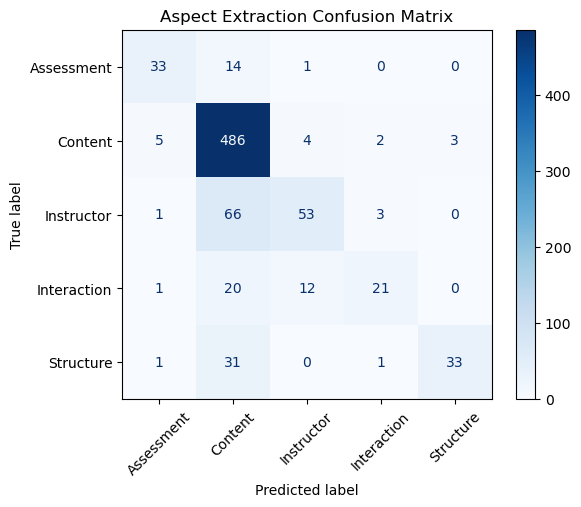


--- Sentiment Classification Model Performance (on 10% Hold-Out Set) ---
              precision    recall  f1-score   support

    Negative       0.77      0.53      0.62        93
     Neutral       0.79      0.71      0.75       223
    Positive       0.83      0.92      0.88       475

    accuracy                           0.82       791
   macro avg       0.79      0.72      0.75       791
weighted avg       0.81      0.82      0.81       791



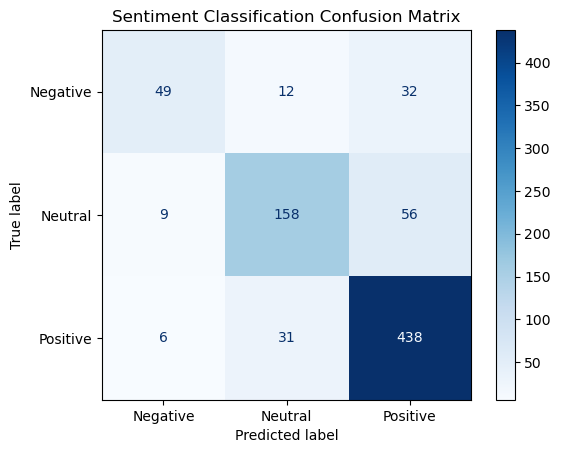

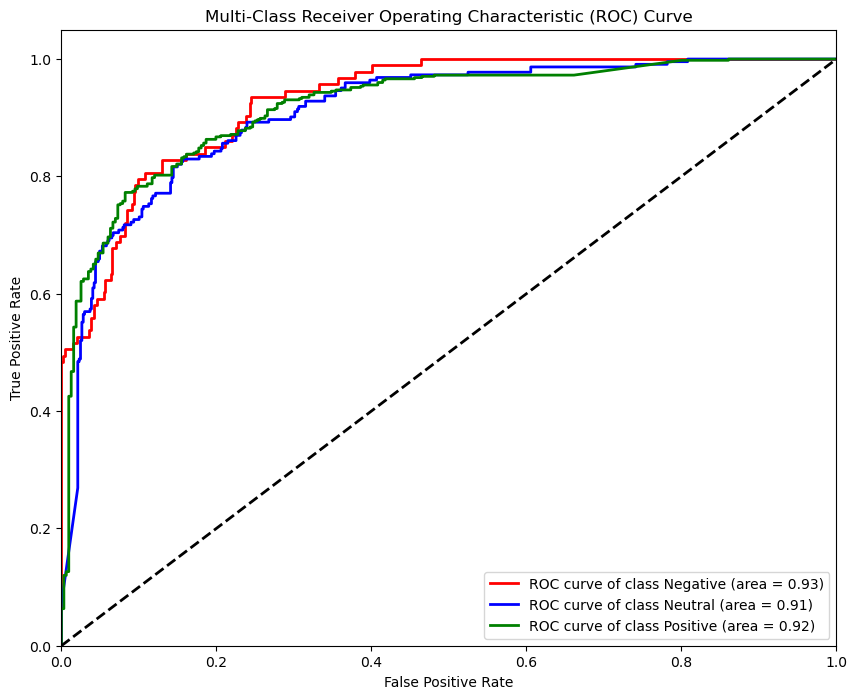

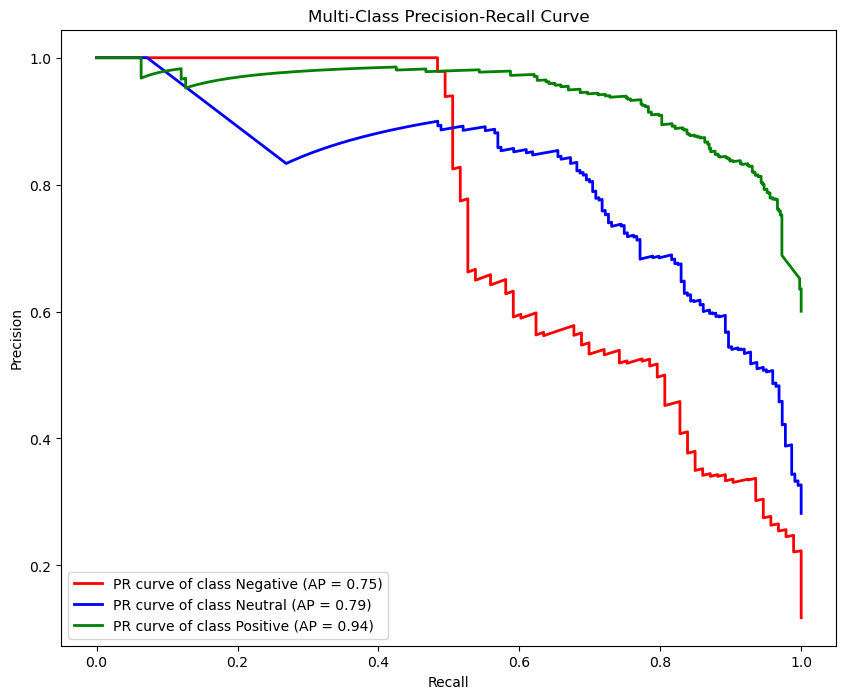

In [12]:
# === Cell 12: Final Unbiased Validation and Visualization ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

print("--- Starting Final Validation on Unseen Hold-Out Data ---")

try:
    # --- 1. Finalize Models for Prediction ---
    print("\nAssigning final models trained on the entire 90% development set...")
    final_aspect_model = aspect_model
    final_dt_sentiment_models = {aspect: dt_sentiment_models[aspect] for aspect in dt_sentiment_models}
    final_svm_sentiment_models = {aspect: svm_sentiment_models[aspect] for aspect in svm_sentiment_models}
    print("Final models assigned successfully.")

    # --- 2. Make Predictions on the 10% Hold-Out Validation Set ---
    print("\nMaking predictions on the 10% hold-out validation set...")
    y_aspect_pred_val = final_aspect_model.predict(X_val)
    y_sentiment_pred_val = []
    y_sentiment_proba_val = []
    sentiment_classes = final_dt_sentiment_models[aspect_labels[0]].classes_

    for i in range(X_val.shape[0]):
        predicted_aspect = y_aspect_pred_val[i]
        text_vector = X_val[i]
        dt_model = final_dt_sentiment_models.get(predicted_aspect)
        svm_model = final_svm_sentiment_models.get(predicted_aspect)
        weights = hybrid_sentiment_weights.get(predicted_aspect)
        if dt_model and svm_model and weights:
            prob_dt = dt_model.predict_proba(text_vector)[0]
            prob_svm = svm_model.predict_proba(text_vector)[0]
            avg_prob = weights['DT'] * prob_dt + weights['SVM'] * prob_svm
            neg_idx = np.where(sentiment_classes == 'Negative')[0][0]
            pos_idx = np.where(sentiment_classes == 'Positive')[0][0]
            if avg_prob[neg_idx] >= optimal_thresholds.get('Negative', 0.5):
                predicted_sentiment = 'Negative'
            elif avg_prob[pos_idx] >= optimal_thresholds.get('Positive', 0.5):
                predicted_sentiment = 'Positive'
            else:
                predicted_sentiment = 'Neutral'
            y_sentiment_pred_val.append(predicted_sentiment)
            y_sentiment_proba_val.append(avg_prob)
        else:
            y_sentiment_pred_val.append('Neutral')
            neutral_idx = np.where(sentiment_classes == 'Neutral')[0][0]
            default_proba = np.zeros(len(sentiment_classes))
            default_proba[neutral_idx] = 1.0
            y_sentiment_proba_val.append(default_proba)

    # --- 3. Evaluate and Display Final Performance Metrics ---
    print("\n--- Final Unbiased Performance Results ---")

    # a) Aspect Extraction Performance
    print("\n--- Aspect Extraction Model Performance (on 10% Hold-Out Set) ---")
    aspect_report_text = classification_report(y_aspect_val, y_aspect_pred_val)
    print(aspect_report_text)
    
    # MODIFIED VISUALIZATION: Aspect Extraction Confusion Matrix
    cm_aspect = confusion_matrix(y_aspect_val, y_aspect_pred_val, labels=final_aspect_model.classes_)
    disp_aspect = ConfusionMatrixDisplay(confusion_matrix=cm_aspect, display_labels=final_aspect_model.classes_)
    disp_aspect.plot(cmap='Blues')
    plt.title('Aspect Extraction Confusion Matrix')
    plt.xticks(rotation=45)
    plt.show()

    # b) Sentiment Classification Performance
    print("\n--- Sentiment Classification Model Performance (on 10% Hold-Out Set) ---")
    senti_report_text = classification_report(y_sentiment_val, y_sentiment_pred_val)
    print(senti_report_text)
    
    # MODIFIED VISUALIZATION: Sentiment Classification Confusion Matrix
    cm_sentiment = confusion_matrix(y_sentiment_val, y_sentiment_pred_val, labels=sentiment_classes)
    disp_sentiment = ConfusionMatrixDisplay(confusion_matrix=cm_sentiment, display_labels=sentiment_classes)
    disp_sentiment.plot(cmap='Blues')
    plt.title('Sentiment Classification Confusion Matrix')
    plt.show()

    # c) ROC Curve and AUC Score for Sentiment
    y_sentiment_val_bin = label_binarize(y_sentiment_val, classes=sentiment_classes)
    y_sentiment_proba_val = np.array(y_sentiment_proba_val)
    n_classes = len(sentiment_classes)

    # Visualization: ROC Curve
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_sentiment_val_bin[:, i], y_sentiment_proba_val[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    colors = cycle(['red', 'blue', 'green'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(sentiment_classes[i], roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # d) Precision-Recall Curve for Sentiment
    # Visualization: Precision-Recall Curve
    precision, recall, average_precision = dict(), dict(), dict()
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_sentiment_val_bin[:, i], y_sentiment_proba_val[:, i])
        average_precision[i] = average_precision_score(y_sentiment_val_bin[:, i], y_sentiment_proba_val[:, i])

    plt.figure(figsize=(10, 8))
    colors = cycle(['red', 'blue', 'green'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(recall[i], precision[i], color=color, lw=2,
                 label='PR curve of class {0} (AP = {1:0.2f})'
                 ''.format(sentiment_classes[i], average_precision[i]))
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Multi-Class Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

except NameError as e:
    print(f"[ERROR] A required model or variable was not found. Please ensure all previous cells have been run successfully.")
    print(f"Details: {e}")
except Exception as e:
    print(f"[ERROR] An unexpected error occurred during final validation: {e}")

In [13]:
# === Cell 13: Save All Final Models, Components, and Database ===

import pandas as pd
import joblib
import os
import sqlite3

print("--- Starting Final Artifact Saving Process ---")

try:
    # --- 1. Save All Trained Models and Components as .joblib files ---
    print("\n--- Saving .joblib files ---")
    artifacts_to_save = {
        "aspect_extraction_model.joblib": final_aspect_model,
        "dt_sentiment_models.joblib": final_dt_sentiment_models,
        "svm_sentiment_models.joblib": final_svm_sentiment_models,
        "hybrid_sentiment_weights.joblib": hybrid_sentiment_weights,
        "tfidf_vectorizer.joblib": tfidf_vectorizer,
        "aspect_labels.joblib": aspect_labels,
        "sentiment_classes.joblib": sentiment_classes
    }
    
    for filename, model_object in artifacts_to_save.items():
        save_path = os.path.join(output_dir_models, filename)
        joblib.dump(model_object, save_path)
        print(f"  Successfully saved: {filename}")
        
    print("\n[SUCCESS] All model components have been saved.")

    # --- 2. Create and Populate the Final SQLite Database ---
    print("\n--- Preparing to Save Final Database ---")
    
    full_aspect_preds = final_aspect_model.predict(tfidf_vectorizer.transform(df_processed['Lemmatized_Text']))
    full_sentiment_preds = []
    full_text_vectors = tfidf_vectorizer.transform(df_processed['Lemmatized_Text'])

    for i in range(full_text_vectors.shape[0]):
        predicted_aspect = full_aspect_preds[i]
        text_vector = full_text_vectors[i]
        dt_model = final_dt_sentiment_models.get(predicted_aspect)
        svm_model = final_svm_sentiment_models.get(predicted_aspect)
        weights = hybrid_sentiment_weights.get(predicted_aspect)
        if dt_model and svm_model and weights:
            prob_dt = dt_model.predict_proba(text_vector)[0]
            prob_svm = svm_model.predict_proba(text_vector)[0]
            avg_prob = weights['DT'] * prob_dt + weights['SVM'] * prob_svm
            predicted_sentiment = sentiment_classes[np.argmax(avg_prob)]
            full_sentiment_preds.append(predicted_sentiment)
        else:
            full_sentiment_preds.append('Neutral')
            
    df_for_db = df_processed.copy()
    df_for_db['predicted_aspect'] = full_aspect_preds
    df_for_db['predicted_sentiment'] = full_sentiment_preds
    
    db_name = "mooc_analyzer.db"
    table_name = "reviews"
    conn = sqlite3.connect(db_name)
    
    print(f"\nWriting {len(df_for_db)} rows to database '{db_name}'...")
    df_for_db.to_sql(table_name, conn, if_exists='replace', index=False)
    conn.close()
    
    print(f"[SUCCESS] Database '{db_name}' has been created and populated.")

except NameError as e:
    print(f"[ERROR] A required variable for saving was not found: {e}. Please ensure Cell 10 ran successfully.")
except Exception as e:
    print(f"[ERROR] An unexpected error occurred while saving artifacts: {e}")

print("\n--- Notebook Execution Complete ---")

--- Starting Final Artifact Saving Process ---

--- Saving .joblib files ---
  Successfully saved: aspect_extraction_model.joblib
  Successfully saved: dt_sentiment_models.joblib
  Successfully saved: svm_sentiment_models.joblib
  Successfully saved: hybrid_sentiment_weights.joblib
  Successfully saved: tfidf_vectorizer.joblib
  Successfully saved: aspect_labels.joblib
  Successfully saved: sentiment_classes.joblib

[SUCCESS] All model components have been saved.

--- Preparing to Save Final Database ---

Writing 7910 rows to database 'mooc_analyzer.db'...
[SUCCESS] Database 'mooc_analyzer.db' has been created and populated.

--- Notebook Execution Complete ---
